# Neural Network (NN1) on the MHAR 5-min Feature Set

## 1. Loading Data
Loading in data from the MALL_5min.csv file

In [8]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_5min.csv"
MALL = pd.read_csv(file_path, index_col='Date', parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()

Shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,BRENT,BRENT_ret,NIKKEI_ret,NIKKEI_sq,SP500_ret_lag,SP500_sq_lag,M1W,M1M,RV_target,logRV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000106,0.000089,0.000141,-9.153100,-9.328531,-8.866447,0.000071,0.000035,0.000000,-0.000960,...,10.30,-0.060282,-0.013746,0.000189,-0.000920,8.458434e-07,0.087690,0.126206,0.000047,-9.966398
1999-01-06,0.000047,0.000090,0.000132,-9.966398,-9.316927,-8.935760,0.000038,0.000009,0.000000,-0.000960,...,10.67,0.035292,0.017657,0.000312,0.013491,1.819949e-04,0.100143,0.187219,0.000237,-8.347779
1999-01-07,0.000237,0.000123,0.000131,-8.347779,-9.004761,-8.938374,0.000110,0.000127,-0.012859,-0.003532,...,11.08,0.037706,0.005044,0.000025,0.021899,4.795626e-04,0.078881,0.184020,0.000168,-8.689606
1999-01-08,0.000168,0.000146,0.000114,-8.689606,-8.832472,-9.082830,0.000079,0.000089,-0.005883,-0.003748,...,11.70,0.054447,-0.010751,0.000116,-0.002053,4.216638e-06,0.078883,0.165510,0.000282,-8.175339
1999-01-11,0.000282,0.000168,0.000117,-8.175339,-8.692020,-9.056351,0.000067,0.000215,-0.025309,-0.008810,...,12.07,0.031134,-0.001744,0.000003,0.004212,1.774503e-05,0.001055,0.140613,0.000191,-8.565468


## Step 2: Define Target and Feature Set (MHAR)

We begin by extracting the target variable and the MHAR feature set, consisting of the 
daily, weekly, and monthly lags of realized variance (RVD, RVW, RVM). This mirrors the 
MHAR dataset definition in Christensen et al. (2023), ensuring a like-for-like comparison 
between the neural network and the HAR benchmark on the same restricted predictor set.

In [11]:
y = MALL["RV_target"].values
X_MHAR = MALL[["RVD", "RVW", "RVM"]].values

## Step 3: Train / Validation / Test Split (70 / 10 / 20)

Following Christensen et al. (2023), the sample is split chronologically into a training 
set (70%), validation set (10%), and test set (20%). The temporal ordering is strictly 
preserved — no shuffling is applied — to respect the time-series structure of the data 
and avoid any lookahead bias. The validation set is used exclusively for hyperparameter 
tuning and network selection, while the test set is reserved for out-of-sample evaluation.

In [14]:
n = len(MALL)
n_train = int(0.70 * n)
n_val = int(0.10 * n)
n_test = n - n_train - n_val

print(f"Training observations:   {n_train}")
print(f"Validation observations: {n_val}")
print(f"Test observations:       {n_test}")
print(f"Training period:   {MALL.index[0].date()} to {MALL.index[n_train - 1].date()}")
print(f"Validation period: {MALL.index[n_train].date()} to {MALL.index[n_train + n_val - 1].date()}")
print(f"Test period:       {MALL.index[n_train + n_val].date()} to {MALL.index[-1].date()}")

Training observations:   3842
Validation observations: 548
Test observations:       1099
Training period:   1999-01-05 to 2014-02-26
Validation period: 2014-02-27 to 2016-04-20
Test period:       2016-04-21 to 2020-08-06


## Step 4: Standardization Using Training Sample Moments

All input features are standardized to zero mean and unit variance using the mean and 
standard deviation computed exclusively from the training set. This follows Christensen 
et al. (2023), who standardize inputs to render estimation scale-invariant and improve 
numerical optimization in the Adam optimizer. Critically, the validation and test sets 
are transformed using the same training-set moments, ensuring no information from future 
observations contaminates the standardization. Note that unlike the GB implementation, 
window-level restandardization will be applied inside the rolling loop below.

In [17]:
X_mean = X_MHAR[:n_train].mean(axis=0)
X_std = X_MHAR[:n_train].std(axis=0, ddof=0)
X_std = np.where(X_std == 0, 1.0, X_std)

X_scaled = (X_MHAR - X_mean) / X_std

X_train_scaled = X_scaled[:n_train]
X_val_scaled = X_scaled[n_train:n_train + n_val]
X_test_scaled = X_scaled[n_train + n_val:]

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

print("Feature set: RVD, RVW, RVM")
print(f"\nFull dataset:   X={X_scaled.shape}, y={y.shape}")
print(f"Training set:   X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val_scaled.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test_scaled.shape}, y={y_test.shape}")
print("\nStandardization check on training sample:")
print(f"  Means: {X_train_scaled.mean(axis=0).round(6)}")
print(f"  Std:   {X_train_scaled.std(axis=0).round(6)}")

Feature set: RVD, RVW, RVM

Full dataset:   X=(5489, 3), y=(5489,)
Training set:   X=(3842, 3), y=(3842,)
Validation set: X=(548, 3), y=(548,)
Test set:       X=(1099, 3), y=(1099,)

Standardization check on training sample:
  Means: [ 0. -0. -0.]
  Std:   [1. 1. 1.]


## Step 5: Define the NN1 Architecture

Following Christensen et al. (2023), we implement the simplest neural network architecture
in their geometric pyramid family, denoted NN1. This consists of a single hidden layer 
with 2 neurons, an input layer receiving the 3 MHAR predictors, and a scalar output layer 
producing the one-day-ahead realized variance forecast. 

The activation function is the Leaky Rectified Linear Unit (L-ReLU) with a negative slope 
coefficient of c=0.01, as proposed by Maas et al. (2013). This is preferred over the 
standard ReLU as it allows gradients to flow even when activations are negative, avoiding 
the so-called dying neuron problem. The output layer applies no activation function, 
consistent with an unrestricted regression setting.

Weights are initialized using the Glorot (Xavier) normal initializer, which draws from a 
truncated normal distribution centered at zero, scaled by the number of input and output 
connections. This initialization strategy is shown to facilitate stable gradient flow 
during early training epochs.

In [20]:
class NN1(nn.Module):
    def __init__(self, input_dim, hidden_dim=2, dropout_rate=0.8):
        super(NN1, self).__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.LeakyReLU(negative_slope=0.01)
        self.dropout = nn.Dropout(p=1 - dropout_rate)
        self.output = nn.Linear(hidden_dim, 1)
        self._initialize_weights()
    
    def _initialize_weights(self):
        nn.init.xavier_normal_(self.hidden.weight)
        nn.init.zeros_(self.hidden.bias)
        nn.init.xavier_normal_(self.output.weight)
        nn.init.zeros_(self.output.bias)
    
    def forward(self, x):
        x = self.hidden(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.output(x)
        return x.squeeze(-1)

# Verify architecture
input_dim = X_train_scaled.shape[1]
model_test = NN1(input_dim=input_dim)
print(model_test)
print(f"\nInput dimension:  {input_dim}")
print(f"Hidden neurons:   2")
print(f"Output dimension: 1")
print(f"\nTotal parameters: {sum(p.numel() for p in model_test.parameters())}")

NN1(
  (hidden): Linear(in_features=3, out_features=2, bias=True)
  (activation): LeakyReLU(negative_slope=0.01)
  (dropout): Dropout(p=0.19999999999999996, inplace=False)
  (output): Linear(in_features=2, out_features=1, bias=True)
)

Input dimension:  3
Hidden neurons:   2
Output dimension: 1

Total parameters: 11


## Step 6: Define the Training Function with Early Stopping

The network is trained by minimizing the mean squared error loss using the Adam optimizer
with a fixed learning rate of 0.001, following Christensen et al. (2023) and the original
specification of Kingma and Ba (2014). Training proceeds for a maximum of 500 epochs.

Early stopping is applied to prevent overfitting: training is halted if the validation 
loss does not improve for 100 consecutive epochs (patience=100), and the weights 
corresponding to the best validation loss are restored. This ensures the retained network 
reflects the best generalization performance observed during training rather than the 
final iterate, which may have overfit to the training sample.

Dropout is applied during training only — all neurons are retained during validation and 
test evaluation, consistent with standard practice.

In [25]:
def train_nn1(X_tr, y_tr, X_vl, y_vl, 
              input_dim, 
              hidden_dim=2,
              dropout_rate=0.8,
              learning_rate=0.001, 
              max_epochs=500, 
              patience=100, 
              seed=None):
    
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
    
    # Convert to tensors
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_vl_t = torch.tensor(X_vl, dtype=torch.float32)
    y_vl_t = torch.tensor(y_vl, dtype=torch.float32)
    
    # Initialize model, loss, optimizer
    model = NN1(input_dim=input_dim, 
                hidden_dim=hidden_dim, 
                dropout_rate=dropout_rate)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    best_val_loss = np.inf
    best_weights = None
    epochs_no_improve = 0
    
    for epoch in range(max_epochs):
        # --- Training step ---
        model.train()
        optimizer.zero_grad()
        y_pred_tr = model(X_tr_t)
        loss_tr = criterion(y_pred_tr, y_tr_t)
        loss_tr.backward()
        optimizer.step()
        
        # --- Validation step ---
        model.eval()
        with torch.no_grad():
            y_pred_vl = model(X_vl_t)
            loss_vl = criterion(y_pred_vl, y_vl_t).item()
        
        # --- Early stopping check ---
        if loss_vl < best_val_loss:
            best_val_loss = loss_vl
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= patience:
            break
    
    # Restore best weights
    model.load_state_dict(best_weights)
    model.eval()
    
    return model, best_val_loss

## Step 6b: Sanity Check — Train a Single Network on the Initial Window

Before proceeding to the full rolling window estimation, we verify that the training 
function works correctly by training a single NN1 network on the initial training window 
with a fixed seed. We check that the validation loss is finite, that the network produces 
reasonable forecasts, and that early stopping is functioning as intended.

In [28]:
# Quick sanity check on initial window
input_dim = X_train_scaled.shape[1]

model_check, val_loss_check = train_nn1(
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_vl=X_val_scaled,
    y_vl=y_val,
    input_dim=input_dim,
    seed=0
)

# Generate forecasts on validation set
model_check.eval()
with torch.no_grad():
    X_vl_t = torch.tensor(X_val_scaled, dtype=torch.float32)
    preds_check = model_check(X_vl_t).numpy()

print(f"Validation MSE (seed=0):      {val_loss_check:.6e}")
print(f"Mean validation forecast:     {preds_check.mean():.6e}")
print(f"Mean actual validation RV:    {y_val.mean():.6e}")
print(f"Any negative forecasts:       {(preds_check < 0).sum()}")
print(f"Any NaN forecasts:            {np.isnan(preds_check).sum()}")

Validation MSE (seed=0):      7.715651e-03
Mean validation forecast:     -5.180160e-02
Mean actual validation RV:    1.221296e-04
Any negative forecasts:       493
Any NaN forecasts:            0


## Step 6c: Standardize the Target Variable

Raw realized variance values are on the order of 1e-04, which creates numerical 
difficulties for gradient-based optimization. Following standard practice, we 
standardize the target variable using training set moments, and back-transform 
forecasts to the original scale for evaluation.

In [31]:
# Compute target scaling parameters from training set only
y_mean = y_train.mean()
y_std = y_train.std(ddof=0)

print(f"Target mean (train): {y_mean:.6e}")
print(f"Target std  (train): {y_std:.6e}")

# Scale targets
y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled   = (y_val   - y_mean) / y_std
y_test_scaled  = (y_test  - y_mean) / y_std

print(f"\nScaled target mean (train): {y_train_scaled.mean():.6f}")
print(f"Scaled target std  (train): {y_train_scaled.std():.6f}")

Target mean (train): 1.608657e-04
Target std  (train): 2.992674e-04

Scaled target mean (train): 0.000000
Scaled target std  (train): 1.000000


In [33]:
model_check, val_loss_check = train_nn1(
    X_tr=X_train_scaled,
    y_tr=y_train_scaled,
    X_vl=X_val_scaled,
    y_vl=y_val_scaled,
    input_dim=input_dim,
    seed=0
)

model_check.eval()
with torch.no_grad():
    X_vl_t = torch.tensor(X_val_scaled, dtype=torch.float32)
    preds_scaled = model_check(X_vl_t).numpy()

# Back-transform to original scale
preds_check = preds_scaled * y_std + y_mean

print(f"Validation MSE scaled (seed=0):    {val_loss_check:.6e}")
print(f"Mean validation forecast (orig):   {preds_check.mean():.6e}")
print(f"Mean actual validation RV:         {y_val.mean():.6e}")
print(f"Any negative forecasts:            {(preds_check < 0).sum()}")
print(f"Any NaN forecasts:                 {np.isnan(preds_check).sum()}")

Validation MSE scaled (seed=0):    1.149677e-01
Mean validation forecast (orig):   1.306810e-04
Mean actual validation RV:         1.221296e-04
Any negative forecasts:            0
Any NaN forecasts:                 0


## Step 7: Ensemble Training on Initial Window

Following Christensen et al. (2023), we train 10 independent NN1 networks with different 
random seeds on the initial training window. Each network is ranked by its validation MSE 
in standardized space. The top 5 networks by validation performance are retained, and the 
final ensemble forecast is constructed as the simple average of their predictions, 
back-transformed to the original scale. We also record the single best network forecast 
separately, analogous to the NN1_1 specification in the paper.

In [36]:
N_ENSEMBLE = 10
N_TOP = 5
input_dim = X_train_scaled.shape[1]

ensemble_records = []

print(f"Training {N_ENSEMBLE} networks on initial window...")
for seed in range(N_ENSEMBLE):
    model_i, val_loss_i = train_nn1(
        X_tr=X_train_scaled,
        y_tr=y_train_scaled,
        X_vl=X_val_scaled,
        y_vl=y_val_scaled,
        input_dim=input_dim,
        seed=seed
    )
    ensemble_records.append({
        "seed": seed,
        "val_loss": val_loss_i,
        "model": model_i
    })
    print(f"  Seed {seed:2d} | Val MSE (scaled): {val_loss_i:.6e}")

# Rank by validation MSE
ensemble_records.sort(key=lambda x: x["val_loss"])
top5 = ensemble_records[:N_TOP]
best = ensemble_records[0]

print(f"\nTop 5 seeds by validation MSE:")
for rank, rec in enumerate(top5):
    print(f"  Rank {rank+1} | Seed {rec['seed']:2d} | Val MSE: {rec['val_loss']:.6e}")

Training 10 networks on initial window...
  Seed  0 | Val MSE (scaled): 1.149677e-01
  Seed  1 | Val MSE (scaled): 1.188120e-01
  Seed  2 | Val MSE (scaled): 1.138585e-01
  Seed  3 | Val MSE (scaled): 1.290916e-01
  Seed  4 | Val MSE (scaled): 1.209766e-01
  Seed  5 | Val MSE (scaled): 1.123865e-01
  Seed  6 | Val MSE (scaled): 1.263697e-01
  Seed  7 | Val MSE (scaled): 1.231746e-01
  Seed  8 | Val MSE (scaled): 1.238221e-01
  Seed  9 | Val MSE (scaled): 1.436973e-01

Top 5 seeds by validation MSE:
  Rank 1 | Seed  5 | Val MSE: 1.123865e-01
  Rank 2 | Seed  2 | Val MSE: 1.138585e-01
  Rank 3 | Seed  0 | Val MSE: 1.149677e-01
  Rank 4 | Seed  1 | Val MSE: 1.188120e-01
  Rank 5 | Seed  4 | Val MSE: 1.209766e-01


## Step 7b: Verify Ensemble Forecast on Validation Set

Before committing to the rolling window estimation, we verify that the top-5 ensemble 
forecast produces sensible predictions on the initial validation window. We compute both 
the single best network forecast and the top-5 ensemble average, and evaluate both 
against actual realized variance in original units.

In [39]:
# Generate forecasts from top 5 networks
X_vl_t = torch.tensor(X_val_scaled, dtype=torch.float32)

preds_all = []
for rec in top5:
    rec["model"].eval()
    with torch.no_grad():
        pred_scaled = rec["model"](X_vl_t).numpy()
        pred_orig = pred_scaled * y_std + y_mean
        preds_all.append(pred_orig)

# Single best network forecast
preds_best = preds_all[0]
preds_best = np.maximum(preds_best, 0.0)

# Top-5 ensemble average
preds_ensemble = np.mean(preds_all, axis=0)
preds_ensemble = np.maximum(preds_ensemble, 0.0)

# Evaluate both
mse_best = np.mean((y_val - preds_best) ** 2)
mse_ensemble = np.mean((y_val - preds_ensemble) ** 2)

print(f"Initial validation window results (original scale):")
print(f"  Single best network MSE:  {mse_best:.6e}")
print(f"  Top-5 ensemble MSE:       {mse_ensemble:.6e}")
print(f"  Actual RV mean:           {y_val.mean():.6e}")
print(f"  Best forecast mean:       {preds_best.mean():.6e}")
print(f"  Ensemble forecast mean:   {preds_ensemble.mean():.6e}")
print(f"  Negative forecasts (best):     {(preds_best < 0).sum()}")
print(f"  Negative forecasts (ensemble): {(preds_ensemble < 0).sum()}")

Initial validation window results (original scale):
  Single best network MSE:  1.006544e-08
  Top-5 ensemble MSE:       1.014874e-08
  Actual RV mean:           1.221296e-04
  Best forecast mean:       1.322975e-04
  Ensemble forecast mean:   1.337882e-04
  Negative forecasts (best):     0
  Negative forecasts (ensemble): 0


## Step 8: Rolling Window Estimation

Following Christensen et al. (2023), we generate one-day-ahead forecasts using a rolling 
window scheme. At each forecast origin, the window advances by one day, maintaining fixed 
training and validation set sizes. For each window, 10 independent NN1 networks are 
trained with different random seeds. Networks are ranked by validation MSE in standardized 
space, and the top 5 are retained. Two forecast series are recorded: the single best 
network forecast (NN1_best) and the top-5 ensemble average (NN1_ensemble). Target 
standardization is recomputed within each window using only the current training portion, 
avoiding any lookahead bias. All forecasts are back-transformed to original scale and 
clipped at zero.

In [42]:
window_size = n_train + n_val
N_ENSEMBLE = 10
N_TOP = 5
input_dim = X_MHAR.shape[1]

forecasts_NN1_best = []
forecasts_NN1_ensemble = []
dates_test = []

start_time = time.time()

for i in range(n_test):
    # --- Define rolling window ---
    X_window = X_MHAR[i:i + window_size]
    y_window = y[i:i + window_size]
    
    X_win_train = X_window[:n_train]
    X_win_val   = X_window[n_train:]
    y_win_train = y_window[:n_train]
    y_win_val   = y_window[n_train:]
    
    # --- Window-level standardization of features ---
    X_mean_w = X_win_train.mean(axis=0)
    X_std_w  = X_win_train.std(axis=0, ddof=0)
    X_std_w  = np.where(X_std_w == 0, 1.0, X_std_w)
    
    X_win_train_s = (X_win_train - X_mean_w) / X_std_w
    X_win_val_s   = (X_win_val   - X_mean_w) / X_std_w
    
    # --- Window-level standardization of target ---
    y_mean_w = y_win_train.mean()
    y_std_w  = y_win_train.std(ddof=0)
    
    y_win_train_s = (y_win_train - y_mean_w) / y_std_w
    y_win_val_s   = (y_win_val   - y_mean_w) / y_std_w
    
    # --- Forecast point ---
    X_fore = X_MHAR[i + window_size].reshape(1, -1)
    X_fore_s = (X_fore - X_mean_w) / X_std_w
    X_fore_t = torch.tensor(X_fore_s, dtype=torch.float32)
    
    # --- Train ensemble ---
    window_records = []
    for seed in range(N_ENSEMBLE):
        model_i, val_loss_i = train_nn1(
            X_tr=X_win_train_s,
            y_tr=y_win_train_s,
            X_vl=X_win_val_s,
            y_vl=y_win_val_s,
            input_dim=input_dim,
            seed=seed
        )
        window_records.append({
            "seed": seed,
            "val_loss": val_loss_i,
            "model": model_i
        })
    
    # --- Rank and select top 5 ---
    window_records.sort(key=lambda x: x["val_loss"])
    top5_w = window_records[:N_TOP]
    
    # --- Generate forecasts and back-transform ---
    preds_w = []
    for rec in top5_w:
        rec["model"].eval()
        with torch.no_grad():
            pred_s = rec["model"](X_fore_t).item()
            pred_orig = pred_s * y_std_w + y_mean_w
            preds_w.append(pred_orig)
    
    forecast_best     = max(preds_w[0], 0.0)
    forecast_ensemble = max(np.mean(preds_w), 0.0)
    
    forecasts_NN1_best.append(forecast_best)
    forecasts_NN1_ensemble.append(forecast_ensemble)
    dates_test.append(MALL.index[i + window_size])
    
    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Day {i+1:4d}/{n_test} | Date: {MALL.index[i + window_size].date()} | Elapsed: {elapsed:.1f} min")

total_elapsed = (time.time() - start_time) / 60
print(f"\nTotal estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated:   {len(forecasts_NN1_best)}")
print(f"Forecast period:       {dates_test[0].date()} to {dates_test[-1].date()}")

  Day  100/1099 | Date: 2016-09-08 | Elapsed: 2.0 min
  Day  200/1099 | Date: 2017-01-27 | Elapsed: 3.9 min
  Day  300/1099 | Date: 2017-06-21 | Elapsed: 5.9 min
  Day  400/1099 | Date: 2017-11-08 | Elapsed: 7.9 min
  Day  500/1099 | Date: 2018-04-04 | Elapsed: 9.9 min
  Day  600/1099 | Date: 2018-08-22 | Elapsed: 11.9 min
  Day  700/1099 | Date: 2019-01-14 | Elapsed: 14.1 min
  Day  800/1099 | Date: 2019-06-06 | Elapsed: 16.2 min
  Day  900/1099 | Date: 2019-10-24 | Elapsed: 18.4 min
  Day 1000/1099 | Date: 2020-03-17 | Elapsed: 20.4 min

Total estimation time: 22.4 minutes
Forecasts generated:   1099
Forecast period:       2016-04-21 to 2020-08-06


In [44]:
# --- Define paths ---
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Neural Networks"
mse_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR/Neural Networks"
os.makedirs(forecast_path, exist_ok=True)
os.makedirs(mse_path, exist_ok=True)

# --- Construct results dataframe ---
results_NN1 = pd.DataFrame({
    "RV_actual":       y_test,
    "RV_forecast_best":     forecasts_NN1_best,
    "RV_forecast_ensemble": forecasts_NN1_ensemble
}, index=dates_test)

# --- Compute errors ---
errors_best     = results_NN1["RV_actual"] - results_NN1["RV_forecast_best"]
errors_ensemble = results_NN1["RV_actual"] - results_NN1["RV_forecast_ensemble"]

mse_best     = np.mean(errors_best ** 2)
mse_ensemble = np.mean(errors_ensemble ** 2)

# --- Save forecasts ---
results_NN1.to_csv(os.path.join(forecast_path, "forecasts_NN1.csv"))

# --- Save MSE summary ---
mse_summary_NN1 = pd.DataFrame({
    "Model": ["NN1_best", "NN1_ensemble"],
    "MSE":  [mse_best,     mse_ensemble],
    "RMSE": [np.sqrt(mse_best), np.sqrt(mse_ensemble)],
    "MAE":  [errors_best.abs().mean(), errors_ensemble.abs().mean()],
    "Mean_Error": [errors_best.mean(), errors_ensemble.mean()]
}).set_index("Model")

mse_summary_NN1.to_csv(os.path.join(mse_path, "mse_summary_NN1.csv"))

# --- Print summary ---
print(f"Forecasts saved to:  {forecast_path}")
print(f"MSE summary saved to: {mse_path}")
print(f"Rows saved: {len(results_NN1)}")
print()
print(mse_summary_NN1.to_string())

Forecasts saved to:  /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Neural Networks
MSE summary saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR/Neural Networks
Rows saved: 1099

                       MSE      RMSE       MAE  Mean_Error
Model                                                     
NN1_best      5.797020e-08  0.000241  0.000066   -0.000021
NN1_ensemble  5.739156e-08  0.000240  0.000067   -0.000021


## Step 10: Visualise Forecast Quality

We plot the one-day-ahead realized volatility forecasts against actual realized variance,
converted to annualized volatility in percentage terms for readability. Both the single 
best network (NN1_best) and the top-5 ensemble average (NN1_ensemble) are shown alongside 
the actual series, allowing visual inspection of forecast quality across different 
volatility regimes including the COVID-19 spike in early 2020.

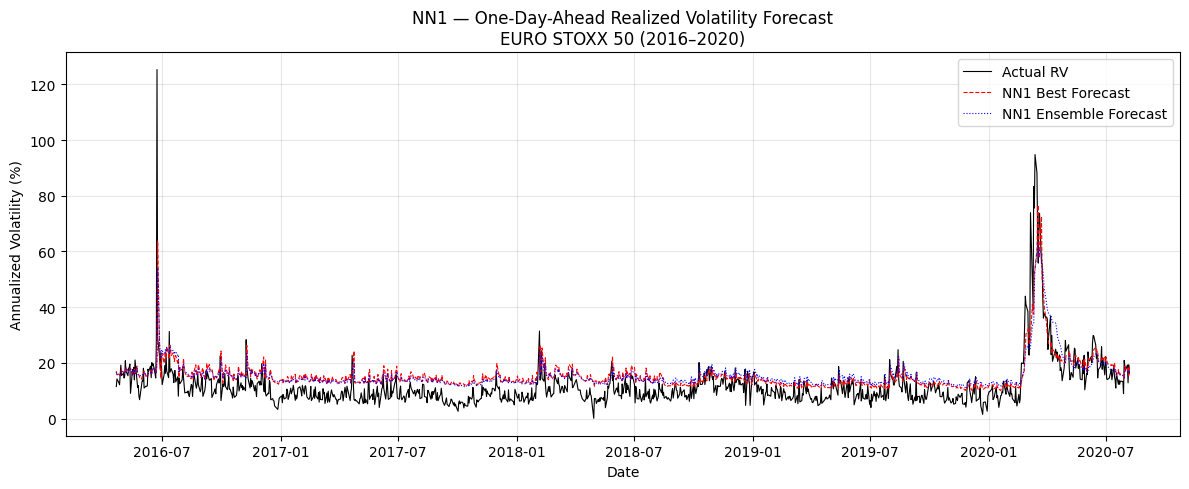


Summary of forecast errors:

NN1 Best:
  Mean error:  -2.084217e-05
  RMSE:        2.407700e-04
  MAE:         6.622606e-05

NN1 Ensemble:
  Mean error:  -2.138609e-05
  RMSE:        2.395654e-04
  MAE:         6.716264e-05


In [48]:
# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual":        np.sqrt(results_NN1["RV_actual"]            * 252) * 100,
    "Forecast_best": np.sqrt(results_NN1["RV_forecast_best"]     * 252) * 100,
    "Forecast_ens":  np.sqrt(results_NN1["RV_forecast_ensemble"] * 252) * 100
}, index=results_NN1.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"],        
        label="Actual RV",            
        color="black", linewidth=0.8)
ax.plot(results_plot["Forecast_best"], 
        label="NN1 Best Forecast",    
        color="red",   linewidth=0.8, linestyle="--")
ax.plot(results_plot["Forecast_ens"],  
        label="NN1 Ensemble Forecast", 
        color="blue",  linewidth=0.8, linestyle=":")
ax.set_title("NN1 — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", 
             fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Error summary ---
print(f"\nSummary of forecast errors:")
print(f"\nNN1 Best:")
errors_best = results_NN1["RV_actual"] - results_NN1["RV_forecast_best"]
print(f"  Mean error:  {errors_best.mean():.6e}")
print(f"  RMSE:        {np.sqrt(mse_best):.6e}")
print(f"  MAE:         {errors_best.abs().mean():.6e}")

print(f"\nNN1 Ensemble:")
errors_ens = results_NN1["RV_actual"] - results_NN1["RV_forecast_ensemble"]
print(f"  Mean error:  {errors_ens.mean():.6e}")
print(f"  RMSE:        {np.sqrt(mse_ensemble):.6e}")
print(f"  MAE:         {errors_ens.abs().mean():.6e}")